In [1]:
import os
import gzip
import glob
import re
import pandas as pd
from multiprocessing import Pool, cpu_count
import fasttext
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

# -----------------------------
# CONFIGURATION
# -----------------------------
DATA_ROOT = "/n/holylabs/LABS/cga/Lab/data/geo-tweets/cga-sbg-tweets/"
OUTPUT_DIR = "/n/home13/zwang2061/ageism/us_only/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FASTTEXT_PATH = "/n/home13/zwang2061/lid.176.bin"
YEARS = list(range(2021, 2022))
NUM_CORES = 44  # Max cores for high performance (FASRC optimized)

# -----------------------------
# KEYWORDS
# -----------------------------
wildcard_keywords = [
    "geront",    # gerontology, gerontocracy
    "senil",     # senile, senility
    "retir",     # retire, retired, retirement
    "pension",   # pension, pensioned, pensioner
    "decrepit",  # decrepit, decrepitude (if needed)
    "wrinkl",    # wrinkly, wrinkled
    "forget",    # forgetful, forgets
    "dement",    # dementia, demented
    "frail",     # frailty
    "vulnerab",  # vulnerable, vulnerability
    "technophob", "outdat", "stuck in the past",  # if you're doing stemmed search
    "grump", "crank",  # grumpy, cranky
    "guid",      # guidance, guide
    "wise",      # wisdom, wiser
    "spry", "feist", "spirited"  # possibly add if you want to match broader forms
]
exact_keywords = [
    "older people", "older adults", "older persons", "old people", "old adults", "old persons", "the old",
    "senior", "seniors", "senior citizens", "boomers", "baby boomers", "aged", "aging", "retirees", "retired",
    "retirement", "grandparents", "grandma", "grandpa", "AARP members", "silver generation", "social security",
    "pensioner", "elderly", "elderly person", "elder", "geriatric", "golden-ager", "OAP", "old fogy",
    "old-age pensioner", "old-timer", "patriarch", "matriarch", "retired person", "veteran", "elder statesman",
    "elder stateswoman", "oldster", "oldie", "Gramps", "gramma", "grammie", "granny", "old hand", "old folk",
    "doyenne", "doyen", "ancient", "ancestor", "antique", "nursing home", "assisted living", "carehome",
    "forerunner", "guide", "lead", "over the hill", "over-the-hill", "gerontocracy", "whippersnapper",
    "senescent", "long-lived", "sexagenarian", "septuagenarian", "octogenarian", "nonagenarian", "centenarian",
    "super centenarian", "of a certain age", "long in the tooth", "unyoung", "senile", "oldish", "superannuated",
    "overaged", "pensioned", "spavined", "tottery", "anile", "overage", "pops", "pop", "pop-pop", "in one's dotage",
    "put someone out to pasture", "losing it", "advanced age", "old as Methuselah", "antediluvian", "wrinkly",
    "wrinkie", "curmudgeon", "beekeeping age", "dinosaur", "old fogey", "geezer", "fuddy-duddy", "fossil", "coot",
    "codger", "OK boomer", "has-been", "old fart", "silver fox", "old hag", "alone", "loneliness", "isolated",
    "diseased", "decrepit", "infirm", "confused", "forgets", "forgetful", "memory loss", "dying", "waiting to die",
    "retire already", "time to go", "dementia", "senile", "senility", "senile dementia", "misplaces", "incompetent",
    "dependent", "decline", "alzheimer's", "deteriorated", "shaky", "wrinkled", "grumpy", "cranky", "given up",
    "walks slowly", "slow", "helpless", "aches and pains", "cannot make up for physical losses",
    "cannot take as much on as before", "getting older makes everything harder",
    "get depressed when I think about getting older", "immobility in later life is not up to me",
    "do not cope as well with problems that arise", "burden", "useless", "less useful", "drain", "frail", "fragile",
    "weak", "vulnerable", "can't keep up", "not tech-savvy", "technophobe", "technologically challenged", "outdated",
    "stuck in the past", "old-fashioned", "out-of-touch", "can't learn", "can't change", "despondent",
    "mildly impaired", "severely impaired", "shrew", "complaining", "ill-tempered", "recluse", "timid", "naïve",
    "nosy neighbor", "bag lady", "rigid", "feeble", "irrelevant", "doddering", "astute", "insightful", "enlightened",
    "creative", "advise", "improving", "learned", "accomplished", "sage", "alert", "guidance", "wise", "wisdom",
    "wiser", "family-oriented", "capable", "active", "positive outlook", "well-groomed", "will-to-live",
    "full of life", "more freedom and time for new interests", "continue to grow as a person",
    "quality of my social life in later years depends on me", "appreciate things more", "nurturing", "warm",
    "caring", "kind", "loving", "respected", "honored", "role model", "mentor", "family anchor", "legacy",
    "heritage", "golden years", "aging gracefully", "graceful aging", "patriotic", "nostalgic", "embrace aging",
    "embracing aging", "age positivity", "experienced", "venerable", "mature", "old woman", "old man", "spry",
    "zesty", "feisty", "spirited", "grandparents", "grandmother", "grandfather"
]

# Compile non-capturing regex pattern
regex_pattern = re.compile(
    r"\b(?:" +
    "|".join([f"{kw}\\w*" for kw in wildcard_keywords] + exact_keywords) +
    r")\b",
    flags=re.IGNORECASE
)

# -----------------------------
# DISPLAY KEYWORDS USED
# -----------------------------
print("\n📋 Keywords included in the regex search:")
print("🔹 Wildcard keywords (prefix search):")
print([f"{kw}\\w*" for kw in wildcard_keywords])
print("\n🔸 Exact match keywords:")
print(exact_keywords)


📋 Keywords included in the regex search:
🔹 Wildcard keywords (prefix search):
['geront\\w*', 'senil\\w*', 'retir\\w*', 'pension\\w*', 'decrepit\\w*', 'wrinkl\\w*', 'forget\\w*', 'dement\\w*', 'frail\\w*', 'vulnerab\\w*', 'technophob\\w*', 'outdat\\w*', 'stuck in the past\\w*', 'grump\\w*', 'crank\\w*', 'guid\\w*', 'wise\\w*', 'spry\\w*', 'feist\\w*', 'spirited\\w*']

🔸 Exact match keywords:
['older people', 'older adults', 'older persons', 'old people', 'old adults', 'old persons', 'the old', 'senior', 'seniors', 'senior citizens', 'boomers', 'baby boomers', 'aged', 'aging', 'retirees', 'retired', 'retirement', 'grandparents', 'grandma', 'grandpa', 'AARP members', 'silver generation', 'social security', 'pensioner', 'elderly', 'elderly person', 'elder', 'geriatric', 'golden-ager', 'OAP', 'old fogy', 'old-age pensioner', 'old-timer', 'patriarch', 'matriarch', 'retired person', 'veteran', 'elder statesman', 'elder stateswoman', 'oldster', 'oldie', 'Gramps', 'gramma', 'grammie', 'granny'

In [3]:
def load_fasttext_model():
    global model
    model = fasttext.load_model(FASTTEXT_PATH)

# Language detection (no text length restriction)
def is_english(text):
    try:
        text = text.strip().replace("\n", "")
        return model.predict(text)[0][0] == '__label__en'
    except:
        return False

# File processing function with regex + language filtering
def process_file(file_path):
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f, sep='\t', on_bad_lines='skip', dtype=str)

        if 'text' not in df.columns:
            return pd.DataFrame()

        df = df.dropna(subset=["text"])
        df = df[df["text"].str.contains(regex_pattern, na=False, regex=True)]
        df = df[df["text"].apply(is_english)]

        return df

    except Exception as e:
        print(f"⚠️ Error in {os.path.basename(file_path)}: {e}")
        return pd.DataFrame()

In [9]:
# 🚀 Block 3 — Yearly Extraction (Auto-run for 2020–2023) — v6

from time import time

def run_year(year):
    input_dir = os.path.join(DATA_ROOT, str(year))
    output_path = os.path.join(OUTPUT_DIR, f"filtered_tweets_{year}.csv.gz")

    if not os.path.exists(input_dir):
        print(f"⚠️ Skipping {year} — input folder not found: {input_dir}", flush=True)
        return

    files = sorted(glob.glob(os.path.join(input_dir, "*.csv.gz")))
    if not files:
        print(f"⚠️ Skipping {year} — no .csv.gz files found.", flush=True)
        return

    print(f"\n─────────────────────────────── 🚀 Processing {year} ({len(files)} files) ───────────────────────────────", flush=True)
    start = time()

    with Pool(processes=NUM_CORES, initializer=load_fasttext_model) as pool:
        results = pool.map(process_file, files)

    filtered_df = pd.concat(results, ignore_index=True)
    filtered_df.to_csv(output_path, index=False, compression="gzip")

    duration = time() - start
    print(f"\n✅ Year {year} complete — {len(filtered_df):,} tweets saved.", flush=True)
    print(f"🕒 Duration: {duration:.2f} seconds", flush=True)
    print(f"📁 Output saved to: {output_path}\n", flush=True)

# ✅ Full auto-run (2020–2023)
for year in YEARS:
    run_year(year)


─────────────────────────────── 🚀 Processing 2021 (8451 files) ───────────────────────────────

✅ Year 2021 complete — 9,681,626 tweets saved.
🕒 Duration: 11034.26 seconds
📁 Output saved to: /n/home13/zwang2061/ageism/filtered_tweets_2021.csv.gz



In [9]:
from time import time

def summarize_extraction(output_folder):
    print("\n────────────────────────────────────── 📊 FINAL SUMMARY ──────────────────────────────────────", flush=True)

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))
    total_tweets = 0
    summary = []

    for file in files:
        year = os.path.basename(file).split("_")[-1].replace(".csv.gz", "")
        try:
            df = pd.read_csv(file, compression='gzip', dtype=str, usecols=["text"])
            count = len(df)
            summary.append((year, count))
            total_tweets += count
            print(f"📅 Year {year}: {count:,} tweets", flush=True)
        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    print("\n✅ Extraction complete across", len(files), "years.", flush=True)
    print(f"🔢 Total tweets extracted: {total_tweets:,}\n", flush=True)

# ✅ Auto-run summary after extraction
start_summary = time()
summarize_extraction(OUTPUT_DIR)
print(f"🕒 Summary generated in {time() - start_summary:.2f} seconds.\n", flush=True)


────────────────────────────────────── 📊 FINAL SUMMARY ──────────────────────────────────────
📅 Year 2020: 8,920,967 tweets
📅 Year 2021: 5,565,088 tweets
📅 Year 2022: 5,074,913 tweets
📅 Year 2023: 1,507,060 tweets

✅ Extraction complete across 4 years.
🔢 Total tweets extracted: 21,068,028

🕒 Summary generated in 165.07 seconds.



In [3]:
# 🚀 Filter tweets to US only (from filtered_tweets_*.csv.gz)

import pandas as pd
import glob, os

# --- CONFIG ---
INPUT_DIR = OUTPUT_DIR  # where your filtered_tweets_*.csv.gz live
OUTPUT_DIR_US = os.path.join(OUTPUT_DIR, "us_only")
os.makedirs(OUTPUT_DIR_US, exist_ok=True)

# Bounding box for continental US + Alaska + Hawaii (approx)
# (min_lon, min_lat, max_lon, max_lat)
US_BBOXES = [
    (-125, 24, -66.9, 49.5),     # Lower 48 states
    (-179.15, 51.2, -129.98, 71.5),  # Alaska
    (-160.24, 18.9, -154.8, 22.4)    # Hawaii
]

def is_in_us(lat, lon):
    for (min_lon, min_lat, max_lon, max_lat) in US_BBOXES:
        if min_lon <= lon <= max_lon and min_lat <= lat <= max_lat:
            return True
    return False

# --- PROCESS ---
files = sorted(glob.glob(os.path.join(INPUT_DIR, "filtered_tweets_*.csv.gz")))
for file in files:
    try:
        print(f"📂 Processing: {file}")
        df = pd.read_csv(file, compression="gzip", dtype=str)

        # Ensure lat/lon are numeric
        df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
        df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
        df = df.dropna(subset=["latitude", "longitude"])

        # Filter to US bounding boxes
        mask = df.apply(lambda row: is_in_us(row["latitude"], row["longitude"]), axis=1)
        df_us = df[mask]

        if not df_us.empty:
            out_path = os.path.join(OUTPUT_DIR_US, os.path.basename(file))
            df_us.to_csv(out_path, index=False, compression="gzip")
            print(f"✅ Saved US-only tweets: {out_path} ({len(df_us)} rows)")
        else:
            print("⚠️ No US tweets found in this file.")

    except Exception as e:
        print(f"❌ Error processing {file}: {e}")

print("\n🎯 US-only tweet filtering complete!")

📂 Processing: /n/home13/zwang2061/ageism/filtered_tweets_2020.csv.gz
✅ Saved US-only tweets: /n/home13/zwang2061/ageism/us_only/filtered_tweets_2020.csv.gz (8920967 rows)
📂 Processing: /n/home13/zwang2061/ageism/filtered_tweets_2021.csv.gz
✅ Saved US-only tweets: /n/home13/zwang2061/ageism/us_only/filtered_tweets_2021.csv.gz (5565088 rows)
📂 Processing: /n/home13/zwang2061/ageism/filtered_tweets_2022.csv.gz
✅ Saved US-only tweets: /n/home13/zwang2061/ageism/us_only/filtered_tweets_2022.csv.gz (5074913 rows)
📂 Processing: /n/home13/zwang2061/ageism/filtered_tweets_2023.csv.gz
✅ Saved US-only tweets: /n/home13/zwang2061/ageism/us_only/filtered_tweets_2023.csv.gz (1507060 rows)

🎯 US-only tweet filtering complete!


In [2]:
# 🚀 Block 5 — Semantic Validation Sample (Auto-run) — v6

import random
from collections import Counter

# -----------------------------
# CONFIGURATION
# -----------------------------
SAMPLE_SIZE_PER_YEAR = 250
SAMPLE_OUTPUT = os.path.join(OUTPUT_DIR, "sample_semantic_validation_us.csv")

# -----------------------------
# FUNCTION
# -----------------------------
def generate_sample(output_folder, sample_size):
    print("\n──────────────────────────────────── 📦 GENERATING SEMANTIC SAMPLE ─────────────────────────────────────", flush=True)
    samples = []
    term_counter = Counter()

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        year = os.path.basename(file).split("_")[-1].replace(".csv.gz", "")
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "text" not in df.columns or df.empty:
                print(f"⚠️ Skipping {year}: No valid text found.", flush=True)
                continue

            n_samples = min(sample_size, len(df))
            df_sample = df.sample(n=n_samples, random_state=42)

            for _, row in df_sample.iterrows():
                text = str(row.get("text", ""))
                found_terms = regex_pattern.findall(text)
                terms_detected = ", ".join(sorted(set(found_terms)))
                term_counter.update(t.lower() for t in found_terms)

                samples.append({
                    "year": year,
                    "text": text,
                    "terms_detected": terms_detected
                })

            print(f"📅 Sampled {n_samples} tweets for year {year}.", flush=True)

        except Exception as e:
            print(f"⚠️ Error sampling {year}: {e}", flush=True)

    if samples:
        pd.DataFrame(samples).to_csv(SAMPLE_OUTPUT, index=False)
        print(f"\n✅ Sample saved to: {SAMPLE_OUTPUT}", flush=True)
        print(f"🔢 Total sample size: {len(samples):,} tweets", flush=True)
    else:
        print("\n⚠️ No samples generated.", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_sample(OUTPUT_DIR, SAMPLE_SIZE_PER_YEAR)


──────────────────────────────────── 📦 GENERATING SEMANTIC SAMPLE ─────────────────────────────────────
📅 Sampled 250 tweets for year 2020.
📅 Sampled 250 tweets for year 2021.
📅 Sampled 250 tweets for year 2022.
📅 Sampled 250 tweets for year 2023.

✅ Sample saved to: /n/home13/zwang2061/ageism/us_only/sample_semantic_validation_us.csv
🔢 Total sample size: 1,000 tweets


In [3]:
# 🚀 Block 5.1 — Preview Semantic Sample (Optional Display)

import pandas as pd

print("\n──────────────────────────────────── 🔍 SEMANTIC SAMPLE PREVIEW ─────────────────────────────────────", flush=True)

try:
    df_sample = pd.read_csv(SAMPLE_OUTPUT)
    display_cols = ["year", "terms_detected", "text"]
    print(df_sample[display_cols].head(10).to_string(index=False))
    print(f"\n🟢 Displaying 10 of {len(df_sample):,} sampled tweets.")
except Exception as e:
    print(f"⚠️ Failed to load semantic sample: {e}")


──────────────────────────────────── 🔍 SEMANTIC SAMPLE PREVIEW ─────────────────────────────────────
 year terms_detected                                                                                                                                                                                                                                                                             text
 2020           Lead                                           Congratulations to Cathy Kirn The Outstanding Kitchen Designer at The Ridley Home Depot‼️Her Rome Bath Remodeling Lead Turned Into A Big Sale Today #4142Proud 🛁🚿💰💰 #2ndHalfServices #LetUsDoItForYou #NewBath https://t.co/nzohyec9zL
 2020      losing it                                                                                                                                                                                                    He’s losing it. Just trying anything at this point #StopAzerbaijaniAggression
 2020       crea

In [4]:
# 🚀 Block 6 — Keyword Frequency Analysis (Auto-run) — v6

# -----------------------------
# CONFIGURATION
# -----------------------------
FREQ_OUTPUT = os.path.join(OUTPUT_DIR, "keyword_frequencies_by_year_us.csv")

# -----------------------------
# FUNCTION
# -----------------------------
def generate_keyword_frequencies(output_folder):
    print("\n──────────────────────────────────── 📈 GENERATING KEYWORD FREQUENCIES ─────────────────────────────────────", flush=True)
    all_counts = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        year = os.path.basename(file).split("_")[-1].replace(".csv.gz", "")
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "text" not in df.columns or df.empty:
                print(f"⚠️ Skipping {year}: No valid text found.", flush=True)
                continue

            year_counter = Counter()

            for text in df["text"].dropna():
                found_terms = regex_pattern.findall(str(text))
                year_counter.update([term.lower() for term in found_terms])

            for term, count in year_counter.items():
                all_counts.append({
                    "year": year,
                    "term": term,
                    "count": count
                })

            print(f"📅 Counted terms for year {year}.", flush=True)

        except Exception as e:
            print(f"⚠️ Error processing {year}: {e}", flush=True)

    if all_counts:
        freq_df = pd.DataFrame(all_counts)
        freq_df = freq_df.sort_values(["year", "term"]).reset_index(drop=True)
        freq_df.to_csv(FREQ_OUTPUT, index=False)
        print(f"\n✅ Keyword frequencies saved to: {FREQ_OUTPUT}", flush=True)
    else:
        print("\n⚠️ No keyword counts generated.", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_keyword_frequencies(OUTPUT_DIR)


──────────────────────────────────── 📈 GENERATING KEYWORD FREQUENCIES ─────────────────────────────────────
📅 Counted terms for year 2020.
📅 Counted terms for year 2021.
📅 Counted terms for year 2022.
📅 Counted terms for year 2023.

✅ Keyword frequencies saved to: /n/home13/zwang2061/ageism/us_only/keyword_frequencies_by_year_us.csv



──────────────────────────────────── 📊 PLOTTING TRENDS ─────────────────────────────────────


<ipython-input-5-b2210a95e973>:46: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
<ipython-input-5-b2210a95e973>:47: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.savefig("ageism_terms_trend.png", dpi=300)  # Save line chart
/n/helmod/apps/centos7/Core/Anaconda3/2021.05-jupyterood-fasrc01/x/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


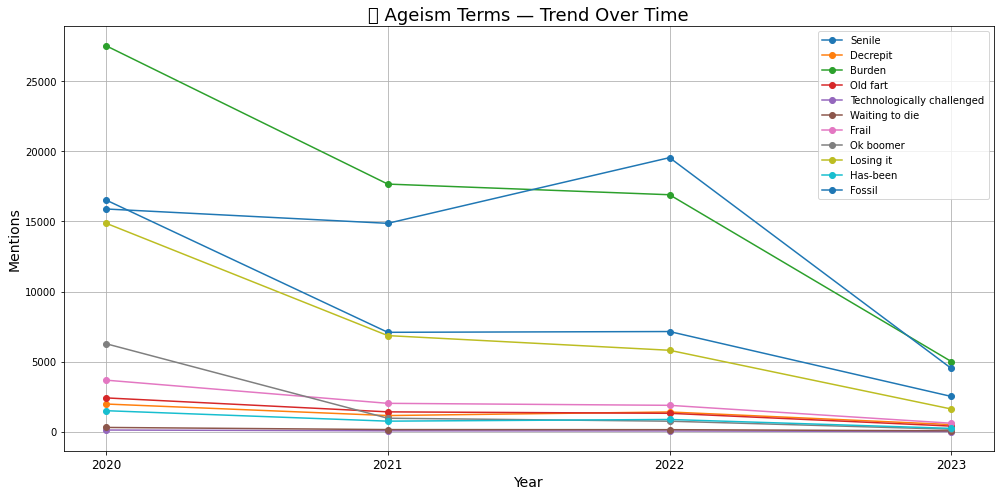

<ipython-input-5-b2210a95e973>:56: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.tight_layout()
<ipython-input-5-b2210a95e973>:57: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  plt.savefig("ageism_terms_heatmap.png", dpi=300)  # Save heatmap
/n/helmod/apps/centos7/Core/Anaconda3/2021.05-jupyterood-fasrc01/x/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 128293 (\N{FIRE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


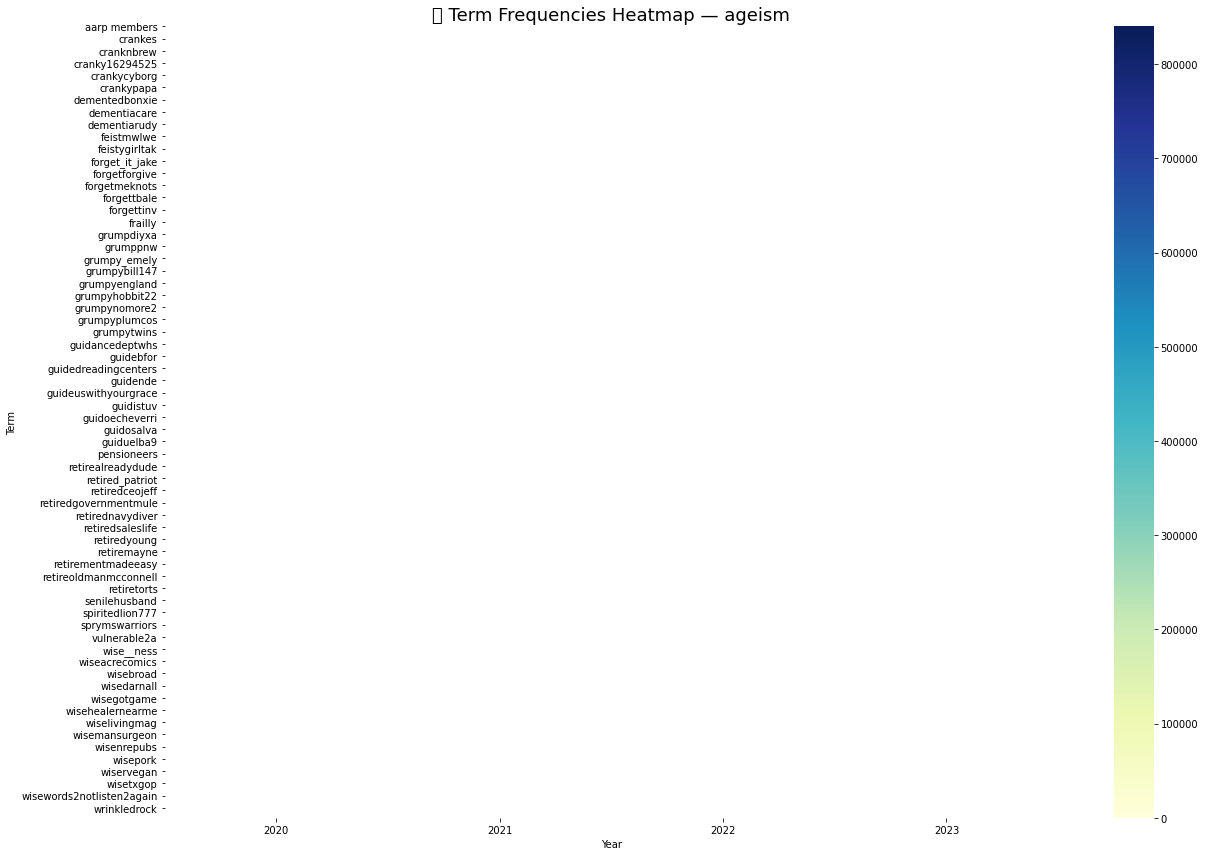


✅ Trend plots generated successfully!


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# -----------------------------
# CONFIGURATION
# -----------------------------
FREQ_FILE = os.path.join(OUTPUT_DIR, "keyword_frequencies_by_year_us.csv")
TOP_TERMS_TO_PLOT = ["senile", "decrepit", "burden", "old fart", "put someone out to pasture", "technologically challenged", "waiting to die", "frail", "OK boomer", "losing it", "has-been", "fossil"]

MIN_YEAR = 2020
MAX_YEAR = 2023

# -----------------------------
# FUNCTION
# -----------------------------
def plot_keyword_trends(freq_file):
    print("\n──────────────────────────────────── 📊 PLOTTING TRENDS ─────────────────────────────────────", flush=True)

    try:
        df = pd.read_csv(freq_file, dtype=str)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

        # Filter years of interest
        df = df[(df["year"] >= MIN_YEAR) & (df["year"] <= MAX_YEAR)]

        # Create pivot for heatmap
        pivot_df = df.pivot_table(index="term", columns="year", values="count", fill_value=0)

        # 📈 Plot line chart for selected top terms
        plt.figure(figsize=(14, 7))
        for term in TOP_TERMS_TO_PLOT:
            subset = df[df["term"] == term.lower()]
            if subset.empty:
                continue  # Skip if the term is not found
            plt.plot(subset["year"].values, subset["count"].values, marker='o', label=term.capitalize())

        plt.title("📈 Ageism Terms — Trend Over Time", fontsize=18)
        plt.xlabel("Year", fontsize=14)
        plt.ylabel("Mentions", fontsize=14)
        plt.legend()
        available_years = sorted(df["year"].unique())
        plt.xticks(ticks=available_years, fontsize=12)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("ageism_terms_trend.png", dpi=300)  # Save line chart
        plt.show()

        # 🔥 Plot full heatmap (optional)
        plt.figure(figsize=(18, 12))
        sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.5, annot=False)
        plt.title("🔥 Term Frequencies Heatmap — ageism", fontsize=18)
        plt.xlabel("Year")
        plt.ylabel("Term")
        plt.tight_layout()
        plt.savefig("ageism_terms_heatmap.png", dpi=300)  # Save heatmap
        plt.show()

        print("\n✅ Trend plots generated successfully!", flush=True)

    except Exception as e:
        print(f"⚠️ Error plotting trends: {e}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
plot_keyword_trends(FREQ_FILE)

In [6]:
# 🚀 Block 8 — Spatial Heatmap of ageism Tweets (Auto-run) — v6

import folium
from folium.plugins import HeatMap
import pandas as pd
import glob
import os

# -----------------------------
# CONFIGURATION
# -----------------------------
MAP_OUTPUT = os.path.join(OUTPUT_DIR, "ageism_spatial_heatmap_us.html")

# -----------------------------
# FUNCTION
# -----------------------------
def generate_spatial_heatmap(output_folder):
    print("\n──────────────────────────────────── 🌎 GENERATING SPATIAL HEATMAP ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                print(f"⚠️ Skipping {file}: No latitude/longitude columns.", flush=True)
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())
            print(f"📦 Loaded {len(df)} geolocated tweets from {os.path.basename(file)}", flush=True)

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if not coords:
        print("\n⚠️ No coordinates found to plot.", flush=True)
        return

    # Center map on global average
    mean_lat = sum(c[0] for c in coords) / len(coords)
    mean_lon = sum(c[1] for c in coords) / len(coords)

    m = folium.Map(location=[mean_lat, mean_lon], zoom_start=2, tiles="CartoDB positron")
    HeatMap(coords, radius=8, blur=6, min_opacity=0.5).add_to(m)

    m.save(MAP_OUTPUT)
    print(f"\n✅ Spatial heatmap saved to: {MAP_OUTPUT}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_spatial_heatmap(OUTPUT_DIR)


──────────────────────────────────── 🌎 GENERATING SPATIAL HEATMAP ─────────────────────────────────────
📦 Loaded 8920967 geolocated tweets from filtered_tweets_2020.csv.gz
📦 Loaded 5565088 geolocated tweets from filtered_tweets_2021.csv.gz
📦 Loaded 5074913 geolocated tweets from filtered_tweets_2022.csv.gz
📦 Loaded 1507060 geolocated tweets from filtered_tweets_2023.csv.gz

✅ Spatial heatmap saved to: /n/home13/zwang2061/ageism/us_only/ageism_spatial_heatmap_us.html



──────────────────────────────────── 📊 PLOTTING YEARLY TWEET COUNTS ─────────────────────────────────────


<ipython-input-7-31a35bd70d12>:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
<ipython-input-7-31a35bd70d12>:34: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig("total_tweets_per_year.png", dpi=300, bbox_inches="tight")  # save
/n/helmod/apps/centos7/Core/Anaconda3/2021.05-jupyterood-fasrc01/x/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


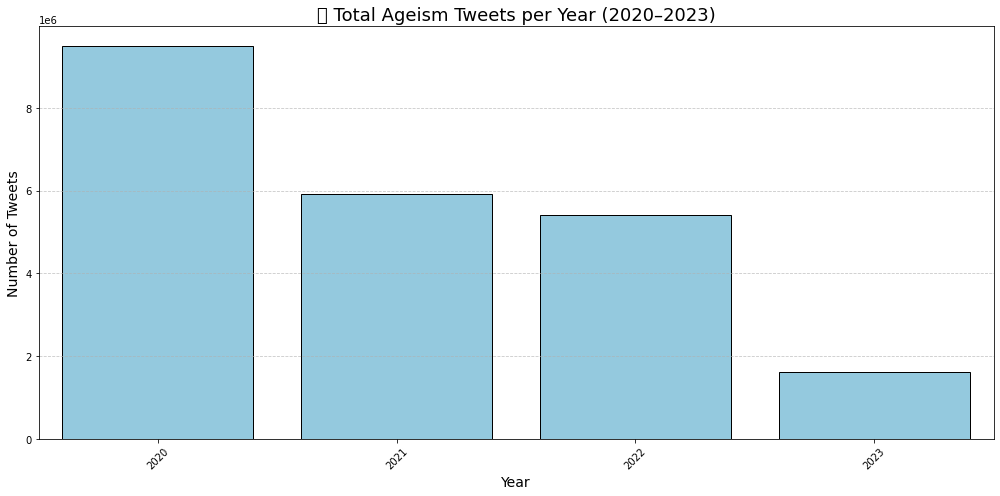

<ipython-input-7-31a35bd70d12>:50: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
<ipython-input-7-31a35bd70d12>:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig("stacked_top10_terms.png", dpi=300, bbox_inches="tight")  # save
/n/helmod/apps/centos7/Core/Anaconda3/2021.05-jupyterood-fasrc01/x/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


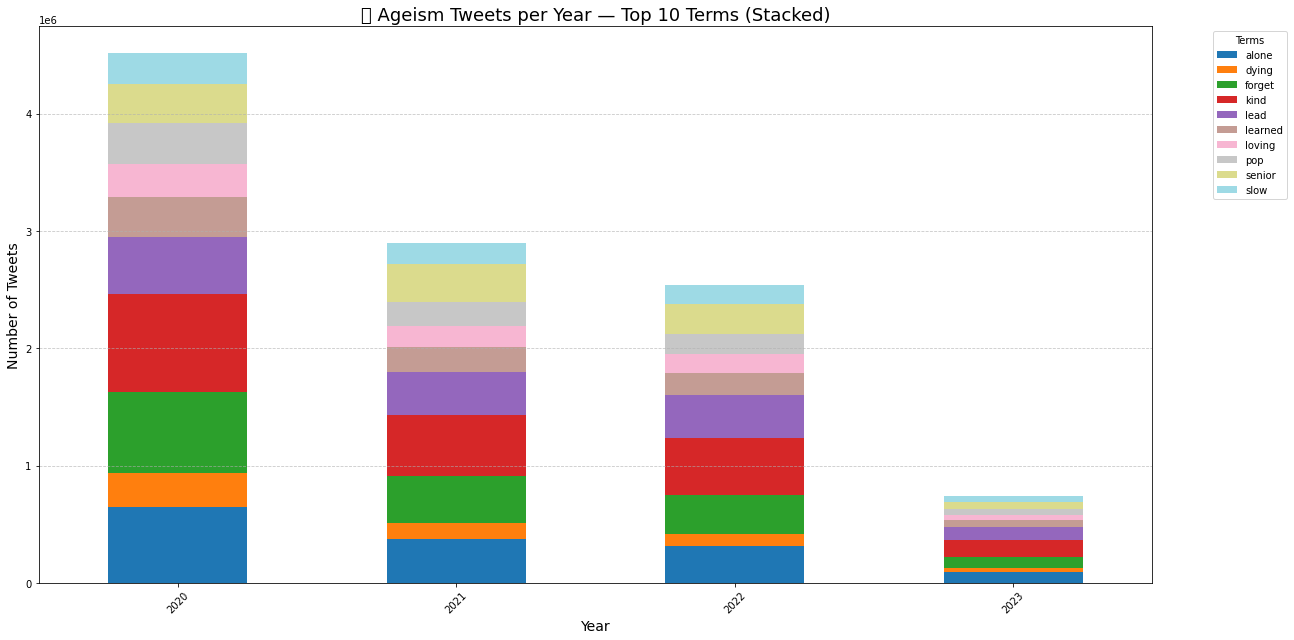


✅ Yearly tweet summary plots generated!


In [7]:
# 🚀 Block 9 — Yearly Tweet Counts and Term Breakdown (Auto-run) — v6

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIGURATION
# -----------------------------
FREQ_FILE = os.path.join(OUTPUT_DIR, "keyword_frequencies_by_year_us.csv")

# -----------------------------
# FUNCTION
# -----------------------------
def plot_yearly_tweet_summary(freq_file):
    print("\n──────────────────────────────────── 📊 PLOTTING YEARLY TWEET COUNTS ─────────────────────────────────────", flush=True)

    try:
        df = pd.read_csv(freq_file, dtype=str)
        df["year"] = df["year"].astype(int)
        df["count"] = df["count"].astype(int)

        # 📈 1. Total tweets per year
        total_per_year = df.groupby("year")["count"].sum().reset_index()

        plt.figure(figsize=(14, 7))
        sns.barplot(x="year", y="count", data=total_per_year, color="skyblue", edgecolor="black")
        plt.title("📊 Total Ageism Tweets per Year (2020–2023)", fontsize=18)
        plt.xlabel("Year", fontsize=14)
        plt.ylabel("Number of Tweets", fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.savefig("total_tweets_per_year.png", dpi=300, bbox_inches="tight")  # save
        plt.show()

        # 📊 2. Stacked barplot of top 10 terms
        top_terms = df.groupby("term")["count"].sum().nlargest(10).index.tolist()
        df_top = df[df["term"].isin(top_terms)]

        pivot_df = df_top.pivot_table(index="year", columns="term", values="count", fill_value=0)

        pivot_df.plot(kind="bar", stacked=True, figsize=(18, 9), colormap=plt.get_cmap("tab20"))
        plt.title("📊 Ageism Tweets per Year — Top 10 Terms (Stacked)", fontsize=18)
        plt.xlabel("Year", fontsize=14)
        plt.ylabel("Number of Tweets", fontsize=14)
        plt.legend(title="Terms", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.grid(True, axis="y", linestyle="--", alpha=0.7)
        plt.tight_layout()
        plt.savefig("stacked_top10_terms.png", dpi=300, bbox_inches="tight")  # save
        plt.show()

        print("\n✅ Yearly tweet summary plots generated!", flush=True)

    except Exception as e:
        print(f"⚠️ Error plotting yearly tweet summary: {e}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
plot_yearly_tweet_summary(FREQ_FILE)

In [10]:
# 🚀 Block 10 — Geospatial Clustering with tiling + OPTICS (OOM-safe, US-only)

import pandas as pd
import numpy as np
import glob, os
import folium
from folium.plugins import MarkerCluster
from sklearn.cluster import OPTICS

# -----------------------------
# CONFIG
# -----------------------------
CLUSTER_OUTPUT = os.path.join(OUTPUT_DIR, "ageism_cluster_map_us.html")
MIN_SAMPLES = 20            # global target; will adapt per tile
CELL = 0.5                  # deg ~55km cells
OVER = 0.1                  # deg overlap ~11km
EPS_KM = 5.0                # neighborhood scale for OPTICS (tune)
EPS_RAD = EPS_KM / 6371.0088

# US bounding boxes (min_lon, min_lat, max_lon, max_lat)
US_BBOXES = [
    (-125.0, 24.0,   -66.9, 49.5),   # Lower 48
    (-179.15, 51.2, -129.98, 71.5),  # Alaska
    (-160.24, 18.9, -154.80, 22.4),  # Hawaii
]

def in_us(lat, lon):
    for (min_lon, min_lat, max_lon, max_lat) in US_BBOXES:
        if (min_lon <= lon <= max_lon) and (min_lat <= lat <= max_lat):
            return True
    return False

# -----------------------------
# FUNCTION
# -----------------------------
def run_spatial_clustering(output_folder):
    print("\n──────────────────────────────────── 🧭 RUNNING GEOSPATIAL CLUSTERING (US only) ─────────────────────────────────────", flush=True)

    # 1) Load & collect coords (US-only)
    coords = []
    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))
    for f in files:
        try:
            df = pd.read_csv(f, compression="gzip", dtype=str, usecols=["latitude", "longitude"])
            df = df.dropna().copy()
            df["latitude"]  = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])
            # US filter
            mask = df.apply(lambda r: in_us(r["latitude"], r["longitude"]), axis=1)
            df = df[mask]
            if not df.empty:
                coords.extend(df[["latitude", "longitude"]].to_numpy().tolist())
        except Exception as e:
            print(f"⚠️ Error reading {os.path.basename(f)}: {e}", flush=True)

    if len(coords) < 100:
        print("⚠️ Not enough US geolocated tweets for clustering.", flush=True)
        return

    # 2) De-duplicate nearby points to shrink N
    arr = np.asarray(coords, dtype=float)
    arr = arr[~np.isnan(arr).any(axis=1)]
    arr = np.unique(np.round(arr, 4), axis=0)  # ~10m grid
    print(f"📉 After dedup: {len(arr):,} points", flush=True)

    # 3) Assign tiles
    lat = arr[:, 0]; lon = arr[:, 1]
    cell_i = np.floor((lat + 90.0)  / CELL).astype(int)
    cell_j = np.floor((lon + 180.0) / CELL).astype(int)
    tile_keys = np.stack([cell_i, cell_j], axis=1)

    # 4) Prepare global labels
    global_labels = np.full(len(arr), -1, dtype=int)
    next_label = 0

    # 5) Cluster per tile (with overlap window), map labels back to core
    uniq_tiles, _ = np.unique(tile_keys, axis=0, return_inverse=True)
    for t_index, (ci, cj) in enumerate(uniq_tiles, start=1):
        core_mask = (cell_i == ci) & (cell_j == cj)
        core_idxs = np.where(core_mask)[0]
        if core_idxs.size < 2:
            continue

        # expanded window with overlap
        lat_min = ci*CELL - 90.0 - OVER
        lat_max = (ci+1)*CELL - 90.0 + OVER
        lon_min = cj*CELL - 180.0 - OVER
        lon_max = (cj+1)*CELL - 180.0 + OVER

        win_mask = (lat >= lat_min) & (lat < lat_max) & (lon >= lon_min) & (lon < lon_max)
        win_idxs = np.where(win_mask)[0]
        n_win = len(win_idxs)
        if n_win < 2:
            continue

        # ✅ adapt min_samples to tile size to avoid ValueError
        local_min_samples = max(2, min(MIN_SAMPLES, n_win))

        X_rad = np.radians(arr[win_idxs])

        mdl = OPTICS(
            min_samples=local_min_samples,
            max_eps=EPS_RAD,
            metric="haversine",
            cluster_method="xi",
            xi=0.05,
        )
        sub_labels = mdl.fit_predict(X_rad)

        # keep only labels for points inside the core (exclude overlap ring)
        core_in_win = np.intersect1d(win_idxs, core_idxs, assume_unique=False)

        # Remap cluster ids to global id space
        unique_sub = [u for u in np.unique(sub_labels) if u != -1]
        if unique_sub and core_in_win.size:
            remap = {u: (next_label + i) for i, u in enumerate(unique_sub)}
            for u in unique_sub:
                members = win_idxs[sub_labels == u]
                members_in_core = np.intersect1d(members, core_in_win, assume_unique=False)
                global_labels[members_in_core] = remap[u]
            next_label += len(unique_sub)

        if t_index % 50 == 0:
            print(f"… processed {t_index}/{len(uniq_tiles)} tiles; next_label={next_label}", flush=True)

    n_clusters = len({x for x in global_labels if x != -1})
    print(f"✅ Tiled clustering complete — {n_clusters} clusters found", flush=True)

    # 6) Build Folium map
    m = folium.Map(location=[39.5, -98.35], zoom_start=4, tiles="CartoDB positron")  # center on US
    marker_cluster = MarkerCluster().add_to(m)

    def color_for(k):
        if k == -1:
            return "gray"
        return f"#{(hash(int(k)) & 0xFFFFFF):06x}"

    for (lat_v, lon_v), lab in zip(arr, global_labels):
        folium.CircleMarker(
            location=[lat_v, lon_v],
            radius=3,
            color=color_for(lab),
            fill=True,
            fill_opacity=0.6,
            popup=f"Cluster {lab}" if lab != -1 else "Noise",
        ).add_to(marker_cluster)

    m.save(CLUSTER_OUTPUT)
    print(f"\n✅ Cluster map saved to: {CLUSTER_OUTPUT}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
run_spatial_clustering(OUTPUT_DIR)



──────────────────────────────────── 🧭 RUNNING GEOSPATIAL CLUSTERING (US only) ─────────────────────────────────────
📉 After dedup: 450,431 points


/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_ep

… processed 100/3879 tiles; next_label=76


/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_ep

… processed 150/3879 tiles; next_label=166


...

… processed 3600/3879 tiles; next_label=7718


/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_ep

… processed 3650/3879 tiles; next_label=7769


/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_eps or all data will be considered outliers.
  warnings.warn(
/n/home13/zwang2061/.local/lib/python3.8/site-packages/sklearn/cluster/_optics.py:631: UserWarning: All reachability values are inf. Set a larger max_ep

✅ Tiled clustering complete — 4745 clusters found

✅ Cluster map saved to: /n/home13/zwang2061/ageism/us_only/ageism_cluster_map_us.html


In [ ]:
# 🚀 Block 11 — Cluster Statistics Generator (Auto-run) — v6

import pandas as pd
import numpy as np
import glob
import os
import hdbscan

# -----------------------------
# CONFIGURATION
# -----------------------------
CLUSTER_SUMMARY_OUTPUT = os.path.join(OUTPUT_DIR, "ageism_cluster_summary_us.csv")
MIN_SAMPLES = 10
MIN_CLUSTER_SIZE = 30

# -----------------------------
# FUNCTION
# -----------------------------
def generate_cluster_statistics(output_folder):
    print("\n──────────────────────────────────── 📋 GENERATING CLUSTER STATISTICS ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if len(coords) < 100:
        print("⚠️ Not enough geolocated tweets for cluster stats.", flush=True)
        return

    # -----------------------------
    # Clustering
    # -----------------------------
    coords_np = np.array(coords)
    coords_rad = np.radians(coords_np)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES, metric='haversine')
    labels = clusterer.fit_predict(coords_rad)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"✅ Clustering complete for stats — {n_clusters} clusters detected.", flush=True)

    # -----------------------------
    # Generate Summary
    # -----------------------------
    df_clusters = pd.DataFrame({
        "latitude": coords_np[:, 0],
        "longitude": coords_np[:, 1],
        "cluster": labels
    })

    df_clusters = df_clusters[df_clusters["cluster"] != -1]  # Exclude noise

    summary = df_clusters.groupby("cluster").agg(
        n_tweets=("cluster", "count"),
        centroid_latitude=("latitude", "mean"),
        centroid_longitude=("longitude", "mean")
    ).reset_index()

    summary = summary.sort_values(by="n_tweets", ascending=False)
    summary.to_csv(CLUSTER_SUMMARY_OUTPUT, index=False)

    print(f"\n✅ Cluster summary saved to: {CLUSTER_SUMMARY_OUTPUT}", flush=True)
    print(f"🔢 Total clusters in summary: {len(summary)}", flush=True)

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_cluster_statistics(OUTPUT_DIR)

In [ ]:
 🚀 Block 12 — Geolocation-Based Tweet Country Summary (Auto-run) — v6

import pandas as pd
import reverse_geocoder as rg
import pycountry
import os
import glob

# -----------------------------
# CONFIGURATION
# -----------------------------
COUNTRY_SUMMARY_OUTPUT = os.path.join(OUTPUT_DIR, "tweets_by_country_us.csv")
BATCH_SIZE = 10000

# -----------------------------
# FUNCTION
# -----------------------------
def generate_country_statistics(output_folder):
    print("\n──────────────────────────────────── 🌍 GENERATING TWEETS BY COUNTRY ─────────────────────────────────────", flush=True)

    coords = []

    files = sorted(glob.glob(os.path.join(output_folder, "filtered_tweets_*.csv.gz")))

    for file in files:
        try:
            df = pd.read_csv(file, compression="gzip", dtype=str)
            if "latitude" not in df.columns or "longitude" not in df.columns:
                continue

            df = df.dropna(subset=["latitude", "longitude"])
            df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
            df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
            df = df.dropna(subset=["latitude", "longitude"])

            coords.extend(df[["latitude", "longitude"]].values.tolist())

        except Exception as e:
            print(f"⚠️ Error reading {file}: {e}", flush=True)

    if not coords:
        print("⚠️ No coordinates found.", flush=True)
        return

    print(f"🔵 Total coordinates to process: {len(coords):,}", flush=True)

    # -----------------------------
    # Reverse Geocoding in Batches
    # -----------------------------
    results = []
    for i in range(0, len(coords), BATCH_SIZE):
        batch = coords[i:i + BATCH_SIZE]
        batch = [(float(lat), float(lon)) for lat, lon in batch]
        print(f"🌎 Geocoding batch {i // BATCH_SIZE + 1} ({len(batch)} points)...", flush=True)
        results.extend(rg.search(batch, mode=2))

    # Extract country codes
    country_codes = [result["cc"] for result in results]
    df_countries = pd.DataFrame(country_codes, columns=["country_code"])

    summary = df_countries.value_counts().reset_index()
    summary.columns = ["country_code", "n_tweets"]

    # Convert ISO2 to country names
    def get_country_name(code):
        try:
            return pycountry.countries.get(alpha_2=code).name
        except:
            return "Unknown"

    summary["country_name"] = summary["country_code"].apply(get_country_name)
    summary = summary[["country_name", "country_code", "n_tweets"]]
    summary = summary.sort_values(by="n_tweets", ascending=False)

    summary.to_csv(COUNTRY_SUMMARY_OUTPUT, index=False)

    print(f"\n✅ Country summary saved to: {COUNTRY_SUMMARY_OUTPUT}", flush=True)
    print(f"🔢 Total countries detected: {len(summary)}", flush=True)

    print("\n🏆 Top 10 countries by number of tweets:")
    print(summary.head(10).to_string(index=False))

# -----------------------------
# AUTO-RUN
# -----------------------------
generate_country_statistics(OUTPUT_DIR)